In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [17]:
df=pd.read_csv("geopolitical_dataset.csv")
print(df.head())

   military_power_ratio  troop_movement  nuclear_capability  nuclear_warheads  \
0              1.061810              46                   0                20   
1              1.926071              11                   0               157   
2              1.597991              61                   0               268   
3              1.397988              79                   0               161   
4              0.734028              87                   1               259   

   gdp_ratio  sanctions_intensity  trade_dependency  ideology_distance  \
0   1.514162                    7          0.949273           0.844864   
1   1.915973                    7          0.879601           0.359676   
2   0.903452                    9          0.907042           0.687234   
3   1.213110                    6          0.991533           0.312834   
4   1.451510                    4          0.208315           0.060906   

   political_stability  historical_conflict  border_distance  news_s

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   military_power_ratio  1000 non-null   float64
 1   troop_movement        1000 non-null   int64  
 2   nuclear_capability    1000 non-null   int64  
 3   nuclear_warheads      1000 non-null   int64  
 4   gdp_ratio             1000 non-null   float64
 5   sanctions_intensity   1000 non-null   int64  
 6   trade_dependency      1000 non-null   float64
 7   ideology_distance     1000 non-null   float64
 8   political_stability   1000 non-null   float64
 9   historical_conflict   1000 non-null   int64  
 10  border_distance       1000 non-null   float64
 11  news_sentiment        1000 non-null   float64
 12  nationalism_index     1000 non-null   float64
 13  leader_aggression     1000 non-null   float64
 14  target                1000 non-null   int64  
dtypes: float64(9), int64(6

In [19]:
# the objectice of this project is to develop   a machine learning based classification modal that predict a geopolitical  state between two countaries
# using  multidimenssional features, the modal ends to classify the relationship into  multiple  countryis , please statigic competitoon , cold war, proxy war,
# direct war based on factor  such as militry strength, nuclear capabilities ,economic conditions , ideological difference ,political stabilitiy ,historical contact
# and santiment analysis derived from pedia and public descodes.

# build  and evalute a neural network modal using proper data validation , testing technique and  optimize modal performance , through hypre parameter tuning and
# validation stretegis,

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
print(df['target'].value_counts())

target
1    438
2    383
3    129
0     49
4      1
Name: count, dtype: int64


In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

df = pd.read_csv("geopolitical_dataset.csv")

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.93
[[ 5  1  0  0]
 [ 1 95  4  0]
 [ 0  3 64  2]
 [ 0  0  3 22]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.96      0.95      0.95       100
           2       0.90      0.93      0.91        69
           3       0.92      0.88      0.90        25

    accuracy                           0.93       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.93      0.93      0.93       200



In [34]:
StandardScaler()

StandardScaler()

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("geopolitical_dataset.csv")

# Sirf nuclear related features
X = df[['nuclear_capability', 'nuclear_warheads']]
y = df['target']

# Dataset divide
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 2)
Test shape: (200, 2)


In [45]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(10, activation='relu'),
    Dense(5, activation='relu', name="hidden_5"),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=25, batch_size=25)

# 🔥 IMPORTANT FIX
model.build(input_shape=(None, X.shape[1]))

intermediate_model = Model(
    inputs=model.inputs,   # 👈 change here (important)
    outputs=model.get_layer("hidden_5").output
)

hidden_output = intermediate_model.predict(X)

print(hidden_output[:5])

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3575 - loss: 0.1128
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3913 - loss: -0.4245
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4050 - loss: -0.9912
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4225 - loss: -1.5925
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4225 - loss: -2.3001
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4225 - loss: -3.1360
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4225 - loss: -4.2170
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4225 - loss: -5.6695
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4225 - loss: -7.6010
Epoch 10/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4225 - loss: -10.0663
Epoch 11/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4225 - loss: -13.2029
Epoch 12/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

In [46]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(10, activation='relu'),
    Dense(5, activation='relu', name="hidden_5"),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3453 - loss: 0.2153 - val_accuracy: 0.4375 - val_loss: 0.0450
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4000 - loss: -0.4678 - val_accuracy: 0.4688 - val_loss: -0.5781
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4109 - loss: -1.3829 - val_accuracy: 0.4688 - val_loss: -1.4508
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4109 - loss: -2.6931 - val_accuracy: 0.4688 - val_loss: -2.7181
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4109 - loss: -4.7281 - val_accuracy: 0.4688 - val_loss: -4.8295
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4109 - loss: -8.0668 - val_accuracy: 0.4688 - val_loss: -8.1013
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4109 - loss: -13.2186 - val_accuracy: 0.4688 - val_loss: -13.3226
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4109 - loss: -20.9842 - val_accuracy: 

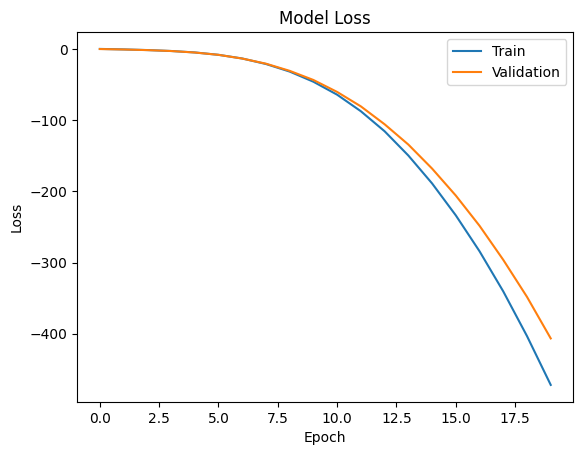

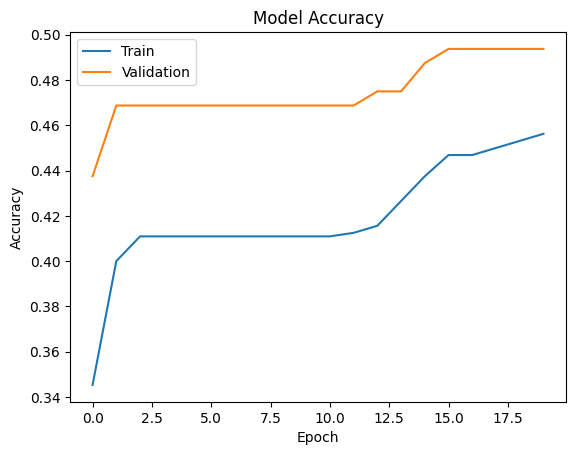

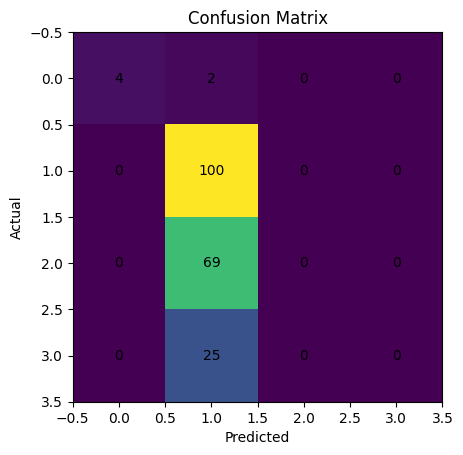

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


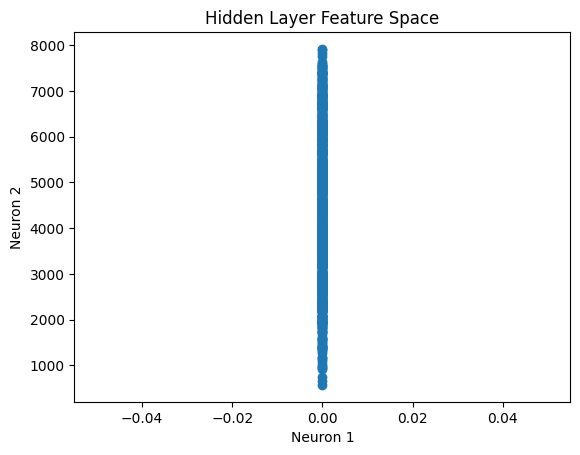

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

# Load data
df = pd.read_csv("geopolitical_dataset.csv")

X = df.drop('target', axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(10, activation='relu'),
    Dense(5, activation='relu', name="hidden_5"),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=10, validation_split=0.2)

# Prediction
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# =========================
# 📊 1. LOSS GRAPH
# =========================
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# =========================
# 📊 2. ACCURACY GRAPH
# =========================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# =========================
# 📊 3. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

# =========================
# 📊 4. HIDDEN LAYER OUTPUT
# =========================
intermediate_model = Model(inputs=model.inputs,
                           outputs=model.get_layer("hidden_5").output)

hidden_output = intermediate_model.predict(X)

# Plot first 2 neurons
plt.figure()
plt.scatter(hidden_output[:, 0], hidden_output[:, 1])
plt.title("Hidden Layer Feature Space")
plt.xlabel("Neuron 1")
plt.ylabel("Neuron 2")
plt.show()

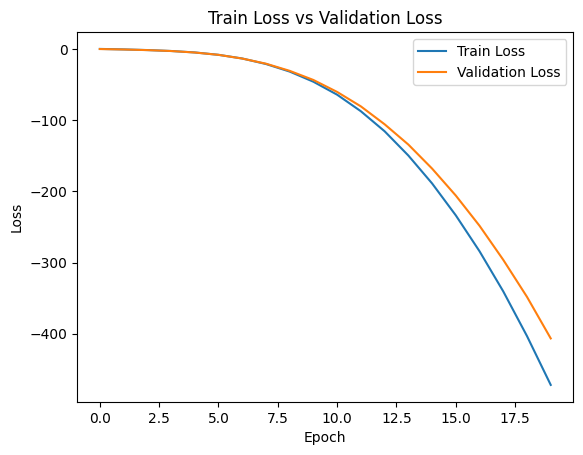

In [49]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Train Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])

plt.show()

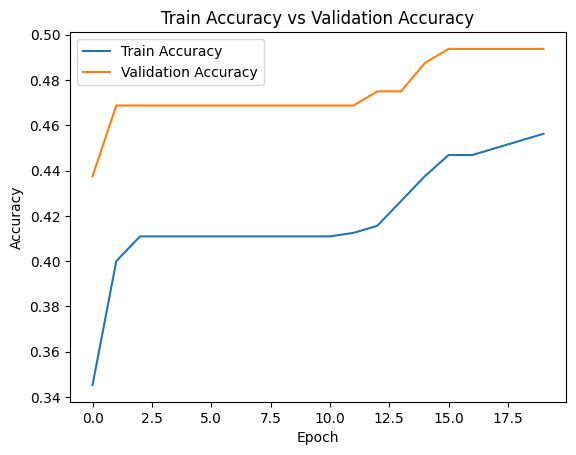

In [50]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Train Accuracy vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])

plt.show()

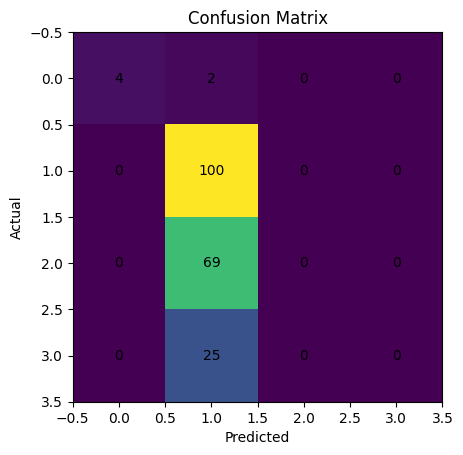

In [51]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


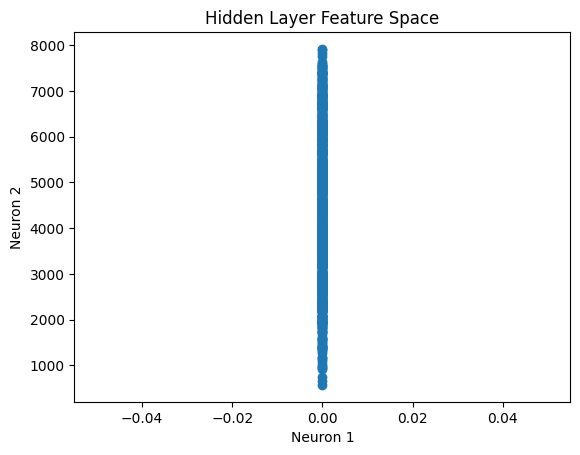

In [52]:
intermediate_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer("hidden_5").output
)

hidden_output = intermediate_model.predict(X)

plt.figure()
plt.scatter(hidden_output[:, 0], hidden_output[:, 1])

plt.title("Hidden Layer Feature Space")
plt.xlabel("Neuron 1")
plt.ylabel("Neuron 2")

plt.show()

In [54]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5200 - loss: -448.0833
Test Loss: -448.0832824707031
Test Accuracy: 0.5199999809265137


In [55]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy: {:.2f}%".format(accuracy * 100))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5200 - loss: -448.0833 
Test Loss: -448.0832824707031
Test Accuracy: 52.00%
